# Extraction des features

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from constants import CANCER, NORMAL, DATA_DIR, PREPARED_DIR, FEATURES_DIR, WITHOUT_LABEL, WITH_LABEL
from PIL import Image, ImageOps

# CONFIGURATION
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32

# ========== CHOIX DE LA COUCHE D'EXTRACTION ==========
# Options: 'avgpool' (par défaut), 'layer4', 'layer3', 'layer2'
EXTRACTION_LAYER = 'avgpool'
# =====================================================

# Paramètres de normalisation
MEAN = np.array([0.5, 0.5, 0.5])
STD = np.array([0.5, 0.5, 0.5])

# TRANSFORMATIONS
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: ImageOps.equalize(img)), # égalisation de l'histogramme
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=MEAN, std=STD)
])

# SIMPLE DATASET
class BrainMRIDataset(Dataset):
    def __init__(self, image_folder, transform=None):
        self.image_paths = list(image_folder.glob("*.png")) + list(image_folder.glob("*.jpg"))
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, str(img_path.name)


# CHARGER RESNET PRE-ENTRAINE ET CHOISIR LA COUCHE
backbone = models.resnet50(pretrained=True)

# Gel explicite des paramètres
for param in backbone.parameters():
    param.requires_grad = False

# Construction du modèle selon la couche choisie
if EXTRACTION_LAYER == 'avgpool':
    resnet = nn.Sequential(
        backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
        backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4,
        backbone.avgpool
    )
    print("Extraction depuis: avgpool (couche finale avant classification)")
    
elif EXTRACTION_LAYER == 'layer4':
    resnet = nn.Sequential(
        backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
        backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4
    )
    print("Extraction depuis: layer4 (dernière couche convolutionnelle)")
    
elif EXTRACTION_LAYER == 'layer3':
    resnet = nn.Sequential(
        backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
        backbone.layer1, backbone.layer2, backbone.layer3
    )
    print("Extraction depuis: layer3 (couche intermédiaire)")
    
elif EXTRACTION_LAYER == 'layer2':
    resnet = nn.Sequential(
        backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
        backbone.layer1, backbone.layer2
    )
    print("Extraction depuis: layer2 (couche bas niveau)")
    
else:
    raise ValueError(f"Couche '{EXTRACTION_LAYER}' non reconnue. Choisir parmi: avgpool, layer4, layer3, layer2")

resnet = resnet.to(DEVICE)
resnet.eval()  # Mode évaluation (pas d'entraînement)

print(f"ResNet50 chargé sur {DEVICE}")

# EXTRACTION DE FEATURES
def extract_features(dataset, model, batch_size=BATCH_SIZE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    features_list = []
    names_list = []
    
    with torch.no_grad():  # Désactive le calcul des gradients (gel)
        for images, names in tqdm(loader, desc="Extraction features"):
            images = images.to(DEVICE)
            features = model(images)
            
            # Aplatir les features (gère tous les cas: avgpool ou couches conv)
            features = torch.flatten(features, start_dim=1)
            
            features_list.append(features.cpu().numpy())
            names_list.extend(names)
    
    # Concaténer tous les batches
    all_features = np.vstack(features_list)
    
    return all_features, names_list

# Cancer
dataset_cancer = BrainMRIDataset(PREPARED_DIR / WITH_LABEL / CANCER, transform=transform)
features_cancer, names_cancer = extract_features(dataset_cancer, resnet)
print(f"Cancer: {features_cancer.shape}")

# Normal
dataset_normal = BrainMRIDataset(PREPARED_DIR / WITH_LABEL / NORMAL, transform=transform)
features_normal, names_normal = extract_features(dataset_normal, resnet)
print(f"Normal: {features_normal.shape}")

# Sans labels
dataset_unlabeled = BrainMRIDataset(PREPARED_DIR / WITHOUT_LABEL, transform=transform)
features_unlabeled, names_unlabeled = extract_features(dataset_unlabeled, resnet)
print(f"Sans labels: {features_unlabeled.shape}")

# SAUVEGARDE DES FEATURES (avec nom de couche dans le fichier)
suffix = f"_{EXTRACTION_LAYER}"
np.save(FEATURES_DIR / f"features_cancer{suffix}.npy", features_cancer)
np.save(FEATURES_DIR / f"features_normal{suffix}.npy", features_normal)
np.save(FEATURES_DIR / f"features_unlabeled{suffix}.npy", features_unlabeled)

print(f"Features extraites depuis '{EXTRACTION_LAYER}' et sauvegardées !")

/usr/local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Extraction depuis: avgpool (couche finale avant classification)
ResNet50 chargé sur cpu


Extraction features: 100% 2/2 [00:00<00:00, -2.82it/s]


Cancer: (50, 2048)


Extraction features: 100% 2/2 [00:01<00:00,  1.04it/s]


Normal: (50, 2048)


Extraction features:   0% 0/44 [00:00<?, ?it/s]


KeyboardInterrupt: 

## Aperçu des transformations

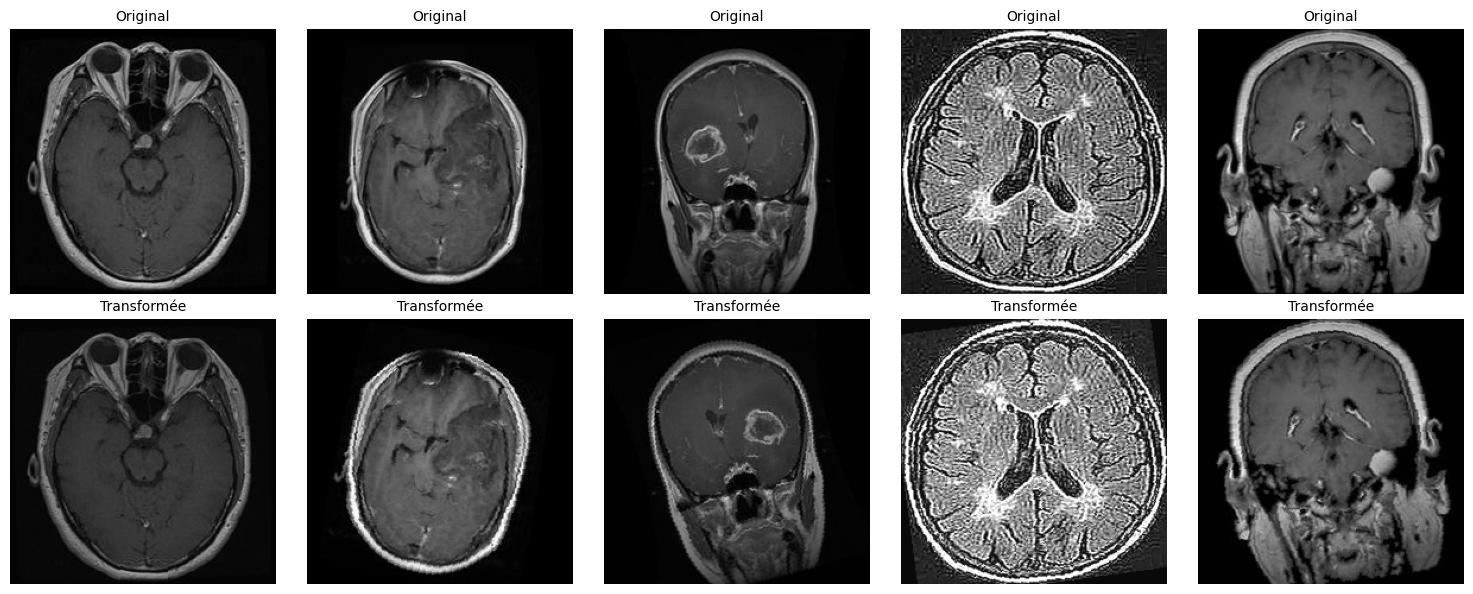

In [2]:
import numpy as np
import matplotlib.pyplot as plt

num_examples = 5
fig, axes = plt.subplots(2, num_examples, figsize=(15, 6))

for i in range(num_examples):
    # Image AVANT transformation (brute depuis le disque)
    img_path = dataset_unlabeled.image_paths[i]
    img_original = Image.open(img_path).convert("RGB")
    
    # Image APRÈS transformation
    image_transformed, name = dataset_unlabeled[i]
    
    # Conversion tensor -> numpy
    img_transformed = image_transformed.numpy().transpose(1, 2, 0)
    
    # Dénormalisation ImageNet
    img_transformed = STD * img_transformed + MEAN
    img_transformed = np.clip(img_transformed, 0, 1)
    
    # Affichage AVANT
    axes[0, i].imshow(img_original)
    axes[0, i].set_title("Original", fontsize=10)
    axes[0, i].axis('off')
    
    # Affichage APRÈS
    axes[1, i].imshow(img_transformed)
    axes[1, i].set_title("Transformée", fontsize=10)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("AVANT", fontsize=12, rotation=0, labelpad=40, va='center')
axes[1, 0].set_ylabel("APRÈS", fontsize=12, rotation=0, labelpad=40, va='center')

plt.tight_layout()
plt.show()